# 3-Year 95% CVaR with ARMA-GARCH & Vine Copula

Pipeline:
1. Load the provided quarterly return dataset.
3. Fit ARMA(1,1)-GARCH(1,1) marginals with normal, t, skewed-t or stable standardized residuals.
4. Fit a vine copula to the PIT residuals.
5. Simulate 3-year quarterly paths and estimate 95% CVaR.

In [ ]:

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import warnings

import altair as alt
import numpy as np
import pandas as pd
import torch
import polars as pl
from arch import arch_model
from arch.univariate import SkewStudent
from scipy.stats import levy_stable
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression

from scipy.optimize import minimize
from scipy.stats import norm, t, jf_skew_t, levy_stable
from scipy.special import gammaln
from dataclasses import dataclass
from typing import Optional

import pyvinecopulib as pv

import torchvinecopulib as tvc

warnings.filterwarnings('ignore')
alt.data_transformers.disable_max_rows()
pd.set_option('display.max_columns', None)

DATA_PATH = Path('../data/processed_returns.csv')
DATE_COLUMN = 'date'
HORIZON_QUARTERS = 12
N_SIMULATIONS = 100_000
ALPHA = 0.05
RESIDUAL_FAMILY = {'SPY': 'normal', 'AGG': 'normal', 'PE': 'normal', 'NPI': 'normal'} # normal/t/skewt/stable
PRIVATE_ASSETS = {'PE', 'NPI'}
PORTFOLIO_WEIGHTS = {'SPY': 0.40, 'AGG': 0.20, 'PE': 0.25, 'NPI': 0.15}
EXPECTED_LOG_RETURNS = {'SPY': np.log((1+0.06)**(1/4)), 'AGG': np.log((1+0.045)**(1/4)), 'PE': np.log((1+0.095)**(1/4)), 'NPI': np.log((1+0.07)**(1/4))}
ASSETS = ['SPY', 'AGG', 'PE', 'NPI']
RNG_SEED = 7

print('Configuration loaded.')

Configuration loaded.


In [2]:
ret_df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
ret_df = ret_df/100
ret_df = np.log(1 + ret_df)
ret_df.index.name = DATE_COLUMN
asset_cols = [column for column in ASSETS if column in ret_df.columns]
if len(asset_cols) != 4:
    asset_cols = [column for column in ret_df.columns if pd.api.types.is_numeric_dtype(ret_df[column])]
    asset_cols = list(asset_cols)

model_df = ret_df[asset_cols].dropna().copy()
ret_pl = pl.from_pandas(model_df.reset_index())
returns_long = ret_pl.unpivot(index=DATE_COLUMN, on=asset_cols, variable_name='asset', value_name='return')

print(f'Raw shape: {ret_df.shape}')
print(f'Modeling shape: {model_df.shape}')
print('Assets:', asset_cols)
ret_pl

Raw shape: (96, 4)
Modeling shape: (81, 4)
Assets: ['SPY', 'AGG', 'PE', 'NPI']


date,SPY,AGG,PE,NPI
datetime[μs],f64,f64,f64,f64
2003-12-31 00:00:00,0.112094,0.003692,0.094241,0.034574
2004-03-31 00:00:00,0.019722,0.02256,-0.044602,0.092938
2004-06-30 00:00:00,0.016208,-0.024996,0.076009,0.062427
2004-09-30 00:00:00,-0.020329,0.030419,0.064438,0.060961
2004-12-31 00:00:00,0.086034,0.009152,0.039644,0.049436
…,…,…,…,…
2022-12-31 00:00:00,0.072887,0.015767,0.020323,-0.235093
2023-03-31 00:00:00,0.071932,0.031811,0.089495,0.051486
2023-06-30 00:00:00,0.083241,-0.00946,0.052148,0.014197


In [3]:
# ── DATA CLASS FOR PARAMETERS ────────────────────────────────────────────────
@dataclass
class GARCHParams:
    mu:        float          # constant mean
    phi:       float          # AR(1) coefficient
    theta:     float          # MA(1) coefficient
    alpha:     float          # ARCH coefficient
    beta:      float          # GARCH coefficient
    omega:     float          # variance intercept (variance-targeted)
    sigma2_lr: float          # long-run variance (sample variance)
    nu:        Optional[float] = None   # degrees of freedom (t / skew-t)
    lam:       Optional[float] = None   # skewness parameter (skew-t only)

    def summary(self, annualise_factor: int = 4):
        print("═" * 45)
        print("  ARMA(1,1)-GARCH(1,1) Parameter Estimates")
        print("═" * 45)
        print(f"  Mean equation")
        print(f"    mu           = {self.mu:.6f}")
        print(f"    phi (AR1)    = {self.phi:.6f}")
        print(f"    theta (MA1)  = {self.theta:.6f}")
        print(f"  Variance equation")
        print(f"    omega        = {self.omega:.6f}  (variance-targeted)")
        print(f"    alpha        = {self.alpha:.6f}")
        print(f"    beta         = {self.beta:.6f}")
        print(f"    alpha+beta   = {self.alpha + self.beta:.6f}  "
              f"({'✓ stationary' if self.alpha + self.beta < 1 else '✗ NON-STATIONARY'})")
        print(f"  Long-run vol   = "
              f"{np.sqrt(self.sigma2_lr * annualise_factor) * 100:.2f}% (annualised)")
        if self.nu is not None:
            print(f"  Tail (nu)      = {self.nu:.4f}")
        if self.lam is not None:
            print(f"  Skew (lambda)  = {self.lam:.4f}")
        print("═" * 45)


# ── LOG-LIKELIHOOD FUNCTIONS ─────────────────────────────────────────────────

def _garch_variance_path(resid: np.ndarray, omega: float,
                         alpha: float, beta: float,
                         sigma2_lr: float) -> np.ndarray:
    """
    Compute the GARCH(1,1) conditional variance path.
    Initialised at the long-run variance (variance targeting start condition).
    """
    n = len(resid)
    sigma2 = np.empty(n)
    sigma2[0] = sigma2_lr                          # initialise at long-run variance
    for t in range(1, n):
        sigma2[t] = omega + alpha * resid[t-1]**2 + beta * sigma2[t-1]
        sigma2[t] = max(sigma2[t], 1e-8)           # floor for numerical safety
    return sigma2


def _residuals(r: np.ndarray, mu: float,
               phi: float, theta: float) -> np.ndarray:
    """
    Compute ARMA(1,1) residuals:  eps_t = r_t - mu - phi*r_{t-1} - theta*eps_{t-1}
    """
    n = len(r)
    eps = np.zeros(n)
    for t in range(1, n):
        eps[t] = r[t] - mu - phi * r[t-1] - theta * eps[t-1]
    return eps


def _nll_normal(params: np.ndarray, r: np.ndarray, sigma2_lr: float) -> float:
    """Gaussian ARMA-GARCH negative log-likelihood with variance targeting."""
    mu, phi, theta, alpha, beta = params

    # Stationarity and positivity guards — return large penalty if violated
    if not (abs(phi) < 1 and abs(theta) < 1):      return 1e10
    if not (alpha > 0 and beta > 0):                return 1e10
    if alpha + beta >= 0.9999:                      return 1e10

    omega = sigma2_lr * (1 - alpha - beta)          # variance targeting
    eps   = _residuals(r, mu, phi, theta)
    sig2  = _garch_variance_path(eps, omega, alpha, beta, sigma2_lr)

    # Gaussian log-likelihood: -0.5 * sum[ log(2pi) + log(sig2) + eps^2/sig2 ]
    nll = 0.5 * np.sum(np.log(2 * np.pi) + np.log(sig2) + eps**2 / sig2)
    return nll


def _nll_student_t(params: np.ndarray, r: np.ndarray, sigma2_lr: float) -> float:
    """Student-t ARMA-GARCH negative log-likelihood with variance targeting."""
    mu, phi, theta, alpha, beta, nu = params

    if not (abs(phi) < 1 and abs(theta) < 1):      return 1e10
    if not (alpha > 0 and beta > 0):                return 1e10
    if alpha + beta >= 0.9999:                      return 1e10
    if nu <= 2.01:                                  return 1e10   # variance must exist

    omega = sigma2_lr * (1 - alpha - beta)
    eps   = _residuals(r, mu, phi, theta)
    sig2  = _garch_variance_path(eps, omega, alpha, beta, sigma2_lr)
    sigma = np.sqrt(sig2)

    # Standardised t log-likelihood
    # Var(t_nu) = nu/(nu-2), so standardise innovations by sqrt(nu/(nu-2))
    scale = np.sqrt(nu / (nu - 2))
    z     = eps / (sigma * scale)      # z ~ t(nu) with unit variance

    log_const = gammaln((nu + 1) / 2) - gammaln(nu / 2) - 0.5 * np.log(np.pi * (nu - 2))
    log_kern  = -((nu + 1) / 2) * np.log(1 + z**2 / (nu - 2))
    log_jacob = -np.log(sigma * scale)  # jacobian for sigma scaling

    nll = -np.sum(log_const + log_kern + log_jacob)
    return nll


def _nll_skewt(params: np.ndarray, r: np.ndarray, sigma2_lr: float) -> float:
    """
    Hansen (1994) Skewed-t ARMA-GARCH negative log-likelihood.
    Captures both fat tails (nu) and asymmetry (lam in (-1, 1)).
    """
    mu, phi, theta, alpha, beta, nu, lam = params

    if not (abs(phi) < 1 and abs(theta) < 1):       return 1e10
    if not (alpha > 0 and beta > 0):                 return 1e10
    if alpha + beta >= 0.9999:                       return 1e10
    if nu <= 2.01:                                   return 1e10
    if not (-0.999 < lam < 0.999):                   return 1e10

    omega = sigma2_lr * (1 - alpha - beta)
    eps   = _residuals(r, mu, phi, theta)
    sig2  = _garch_variance_path(eps, omega, alpha, beta, sigma2_lr)
    sigma = np.sqrt(sig2)
    z     = eps / sigma

    # Hansen (1994) constants
    c = np.exp(gammaln((nu + 1) / 2) - gammaln(nu / 2)) / np.sqrt(np.pi * (nu - 2))
    a = 4 * lam * c * ((nu - 2) / (nu - 1))
    b = np.sqrt(1 + 3 * lam**2 - a**2)

    # Split domain: f(z) depends on sign of b*z + a
    bza = b * z + a
    ll  = np.empty(len(z))

    pos = bza >= 0
    # Right tail (z >= -a/b)
    ll[pos]  = (np.log(b) + np.log(c) - np.log(sigma[pos])
                - ((nu + 1) / 2)
                * np.log(1 + (bza[pos] / (1 + lam)) ** 2 / (nu - 2)))
    # Left tail (z < -a/b)
    ll[~pos] = (np.log(b) + np.log(c) - np.log(sigma[~pos])
                - ((nu + 1) / 2)
                * np.log(1 + (bza[~pos] / (1 - lam)) ** 2 / (nu - 2)))

    return -np.sum(ll)

def _nll_stable(params: np.ndarray, r: np.ndarray, sigma2_lr: float) -> float:
    """
    Stable ARMA-GARCH negative log-likelihood with variance targeting.
    Captures fat tails and skewness in a single distribution.
    Note: Stable distribution has no closed-form PDF, so we use scipy's levy_stable.
    """
    mu, phi, theta, alpha, beta, stable_alpha, stable_beta, stable_loc, stable_scale = params

    if not (abs(phi) < 1 and abs(theta) < 1):       return 1e10
    if not (alpha > 0 and beta > 0):                 return 1e10
    if alpha + beta >= 0.9999:                       return 1e10
    if not (0.1 < stable_alpha <= 2.0):             return 1e10
    if not (-1.0 <= stable_beta <= 1.0):            return 1e10

    omega = sigma2_lr * (1 - alpha - beta)
    eps   = _residuals(r, mu, phi, theta)
    sig2  = _garch_variance_path(eps, omega, alpha, beta, sigma2_lr)
    sigma = np.sqrt(sig2)

    # Standardise residuals to fit the stable distribution
    z = eps / sigma

    # Compute log-likelihood using scipy's levy_stable PDF
    nll = -np.sum(levy_stable.logpdf(z, stable_alpha, stable_beta,
                                      loc=stable_loc, scale=stable_scale))
    return nll


# ── MAIN FITTING FUNCTION ────────────────────────────────────────────────────

def fit_garch(
    returns:   pd.Series,
    dist:      str = 'skewt',
    n_restarts: int = 5,
    seed:      int = 42
) -> GARCHParams:
    """
    Fit ARMA(1,1)-GARCH(1,1) with variance targeting via direct MLE.
    No arch library — pure numpy/scipy.

    Parameters
    ----------
    returns : pd.Series
        Return series (quarterly decimals, e.g. 0.05 = 5%)
    dist : str
        'normal', 't', or 'skewt'
    n_restarts : int
        Number of random restarts to escape local optima
    seed : int

    Returns
    -------
    GARCHParams dataclass
    """
    rng      = np.random.default_rng(seed)
    r        = returns.values.astype(float)
    sigma2_lr = r.var()

    dist_map = {
        'normal': (_nll_normal,    ['mu','phi','theta','alpha','beta']),
        't':      (_nll_student_t, ['mu','phi','theta','alpha','beta','nu']),
        'skewt':  (_nll_skewt,     ['mu','phi','theta','alpha','beta','nu','lam']),
        'stable': (_nll_stable,    ['mu','phi','theta','alpha','beta','stable_alpha','stable_beta','stable_loc','stable_scale'])
    }
    if dist not in dist_map:
        raise ValueError(f"dist must be one of {list(dist_map.keys())}")

    nll_fn, param_names = dist_map[dist]

    # ── Starting values ──────────────────────────────────────────────────────
    def make_x0(random=False):
        if random:
            phi_0   = rng.uniform(-0.3, 0.3)
            theta_0 = rng.uniform(-0.3, 0.3)
            ab      = rng.uniform(0.70, 0.95)
            alpha_0 = rng.uniform(0.03, 0.25)
            beta_0  = ab - alpha_0
        else:
            phi_0, theta_0, alpha_0, beta_0 = 0.1, 0.05, 0.10, 0.85

        base = [r.mean(), phi_0, theta_0, alpha_0, beta_0]
        if dist == 't':     return base + [8.0]
        if dist == 'skewt': return base + [8.0, -0.1]
        return base

    # ── Bounds ───────────────────────────────────────────────────────────────
    base_bounds = [
        (-0.2, 0.2),    # mu
        (-0.95, 0.95),  # phi
        (-0.95, 0.95),  # theta
        (1e-6, 0.1),   # alpha
        (1e-6, 0.9999), # beta
    ]
    if dist == 't':     bounds = base_bounds + [(2.1, 50.0)]
    elif dist == 'skewt': bounds = base_bounds + [(2.1, 50.0), (-0.999, 0.999)]
    else:               bounds = base_bounds

    # ── alpha + beta < 1 constraint ──────────────────────────────────────────
    constraints = [{
        'type': 'ineq',
        'fun':  lambda x: 0.9999 - (x[3] + x[4])   # alpha + beta < 0.9999
    }]

    # ── Multi-start optimisation ─────────────────────────────────────────────
    best_result = None
    best_nll    = np.inf

    for i in range(n_restarts):
        x0 = make_x0(random=(i > 0))
        try:
            res = minimize(
                nll_fn,
                x0,
                args=(r, sigma2_lr),
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                options={'ftol': 1e-10, 'maxiter': 2000, 'disp': False}
            )
            if res.success and res.fun < best_nll:
                best_nll    = res.fun
                best_result = res
        except Exception:
            continue

    if best_result is None:
        raise RuntimeError("All optimisation restarts failed. "
                           "Check your return series for NaNs or extreme outliers.")

    x = best_result.x
    alpha, beta = x[3], x[4]
    omega = sigma2_lr * (1 - alpha - beta)

    params = GARCHParams(
        mu=x[0], phi=x[1], theta=x[2],
        alpha=alpha, beta=beta, omega=omega,
        sigma2_lr=sigma2_lr,
        nu=x[5]  if dist in ('t', 'skewt') else None,
        lam=x[6] if dist == 'skewt'        else None,
    )

    print(f"Converged in {best_result.nit} iterations  |  "
          f"NLL = {best_nll:.4f}  |  dist = {dist}")
    params.summary()
    return params


# ── INFORMATION CRITERIA ─────────────────────────────────────────────────────

def model_aic_bic(nll: float, n_params: int, n_obs: int) -> dict:
    aic = 2 * nll + 2 * n_params
    bic = 2 * nll + n_params * np.log(n_obs)
    return {'AIC': aic, 'BIC': bic, 'NLL': nll}


def select_distribution(returns: pd.Series, n_restarts: int = 5) -> str:
    """Fit all three distributions and select by BIC."""
    r = returns.values
    n = len(r)
    results = {}

    n_params_map = {'normal': 5, 't': 6, 'skewt': 7}

    print("Comparing distributions by BIC...\n")
    for dist in ['normal', 't', 'skewt']:
        try:
            params = fit_garch(returns, dist=dist, n_restarts=n_restarts)
            nll_fn = {'normal': _nll_normal,
                      't':      _nll_student_t,
                      'skewt':  _nll_skewt}[dist]
            x = [params.mu, params.phi, params.theta, params.alpha, params.beta]
            if params.nu  is not None: x.append(params.nu)
            if params.lam is not None: x.append(params.lam)
            nll = nll_fn(np.array(x), r, params.sigma2_lr)
            ic  = model_aic_bic(nll, n_params_map[dist], n)
            results[dist] = (params, ic)
            print(f"  {dist:<8}  AIC={ic['AIC']:.2f}  BIC={ic['BIC']:.2f}\n")
        except Exception as e:
            print(f"  {dist} failed: {e}")

    best = min(results, key=lambda d: results[d][1]['BIC'])
    print(f"  → Best distribution by BIC: {best.upper()}")
    return best, results[best][0]

In [4]:
# Fit a single distribution
fit_garch(model_df['SPY'].dropna(), dist='normal', n_restarts=5)
fit_garch(model_df['AGG'].dropna(), dist='normal', n_restarts=5)
fit_garch(model_df['PE'].dropna(), dist='normal', n_restarts=5)
fit_garch(model_df['NPI'].dropna(), dist='t', n_restarts=5)

Converged in 12 iterations  |  NLL = -93.6083  |  dist = normal
═════════════════════════════════════════════
  ARMA(1,1)-GARCH(1,1) Parameter Estimates
═════════════════════════════════════════════
  Mean equation
    mu           = 0.021492
    phi (AR1)    = 0.001107
    theta (MA1)  = -0.013452
  Variance equation
    omega        = 0.000925  (variance-targeted)
    alpha        = 0.100000
    beta         = 0.755754
    alpha+beta   = 0.855754  (✓ stationary)
  Long-run vol   = 16.01% (annualised)
═════════════════════════════════════════════
Converged in 20 iterations  |  NLL = -194.3207  |  dist = normal
═════════════════════════════════════════════
  ARMA(1,1)-GARCH(1,1) Parameter Estimates
═════════════════════════════════════════════
  Mean equation
    mu           = 0.016396
    phi (AR1)    = -0.907443
    theta (MA1)  = 0.950000
  Variance equation
    omega        = 0.000065  (variance-targeted)
    alpha        = 0.091649
    beta         = 0.783630
    alpha+beta   = 0

GARCHParams(mu=np.float64(0.009762743708444164), phi=np.float64(0.566730719133551), theta=np.float64(-0.10364388882431193), alpha=np.float64(0.1), beta=np.float64(0.8998999684888177), omega=np.float64(1.1819702139295618e-06), sigma2_lr=np.float64(0.011815978784677989), nu=np.float64(3.650754166904696), lam=None)

In [5]:
def fit_arma_garch_marginal(series: pd.Series, residual_family: str = 'normal') -> dict:
    values = series.dropna().astype(float)

    garch_fit = fit_garch(values, dist=residual_family, n_restarts=5)
    
    values = values.to_numpy()
    eps_arr = _residuals(values, garch_fit.mu, garch_fit.phi, garch_fit.theta)
    sigma2_arr = _garch_variance_path(eps_arr, garch_fit.omega, garch_fit.alpha, garch_fit.beta, garch_fit.sigma2_lr)
    sigma_arr = np.sqrt(sigma2_arr)
    std_resid = eps_arr / sigma_arr
    eps = 1e-10

    if residual_family == "normal":
        normal_params = norm.fit(std_resid[~np.isnan(std_resid)])
        u = np.asarray(norm.cdf(std_resid[~np.isnan(std_resid)], *normal_params), dtype=float)

        def ppf_fn(q: np.ndarray) -> np.ndarray:
            q = np.clip(np.asarray(q, dtype=float), eps, 1.0 - eps)
            return norm.ppf(q, *normal_params)

        dist_summary = {"family": "normal", "mean": normal_params[0], "variance": normal_params[1] ** 2}

    elif residual_family == 't':
        from arch.univariate import StudentsT

        t_params = t.fit(std_resid)
        u = np.asarray(t.cdf(std_resid, *t_params), dtype=float)

        def ppf_fn(q: np.ndarray) -> np.ndarray:
            q = np.clip(np.asarray(q, dtype=float), eps, 1.0 - eps)
            return np.asarray(t.ppf(q, *t_params), dtype=float)

        dist_summary = {'family': 't', 'nu': float(t_params[0]), 'loc': float(t_params[1]), 'scale': float(t_params[2])}

    elif residual_family == "skewt":
        skewt_params = jf_skew_t.fit(std_resid)
        u = np.asarray(jf_skew_t.cdf(std_resid, *skewt_params), dtype=float)

        def ppf_fn(q: np.ndarray) -> np.ndarray:
            q = np.clip(np.asarray(q, dtype=float), eps, 1.0 - eps)
            return np.asarray(jf_skew_t.ppf(q, *skewt_params), dtype=float)

        dist_summary = {'family': 'skewt', 'eta': float(skewt_params[0]), 'lambda': float(skewt_params[1])}

    elif residual_family == 'stable':
        stable_params = levy_stable.fit(std_resid)
        u = np.asarray(levy_stable.cdf(std_resid, *stable_params), dtype=float)

        def ppf_fn(q: np.ndarray) -> np.ndarray:
            q = np.clip(np.asarray(q, dtype=float), eps, 1.0 - eps)
            return np.asarray(levy_stable.ppf(q, *stable_params), dtype=float)

        dist_summary = {
            'family': 'stable',
            'stable_alpha': float(stable_params[0]),
            'stable_beta': float(stable_params[1]),
            'stable_loc': float(stable_params[2]),
            'stable_scale': float(stable_params[3]),
        }
    else:
        raise ValueError('residual_family must be either skewt, t, normal, or stable.')

    u = np.clip(u, eps, 1.0 - eps)

    # # conditional_volatility = np.asarray(garch_fit.conditional_volatility, dtype=float)
    model_summary = {
        'Asset': series.name,
        'N': int(values.size),
        # 'GARCH_AIC': float(garch_fit.aic),
        # 'GARCH_BIC': float(garch_fit.bic),
        'Const':float(garch_fit.mu),
        'Simulation_Const': EXPECTED_LOG_RETURNS[series.name]*(1 - garch_fit.phi),
        'Phi':float(garch_fit.phi),
        'Theta':float(garch_fit.theta),
        'Omega': float(garch_fit.omega),
        'Alpha': float(garch_fit.alpha),
        'Beta': float(garch_fit.beta),
        'Persistence': float(garch_fit.alpha + garch_fit.beta),
    }
    model_summary.update(dist_summary)

    return {
        'asset': series.name,
        'observed': values,
        'garch_fit': garch_fit,
        'std_resid': std_resid,
        'pit': u,
        'ppf': ppf_fn,
        'model_summary': model_summary,
        'last_return': float(values[-1]),
        'last_sigma': float(sigma_arr[-1]),
        'last_std_resid': float(std_resid[-1]),
        'last_eps': float(eps_arr[-1]),
        'const':float(garch_fit.mu),
        'simulation_const': EXPECTED_LOG_RETURNS[series.name]*(1 - garch_fit.phi),
        'phi':float(garch_fit.phi),
        'theta':float(garch_fit.theta),
        'omega': float(garch_fit.omega),
        'alpha': float(garch_fit.alpha),
        'beta': float(garch_fit.beta),
    }


marginals = [fit_arma_garch_marginal(model_df[column], residual_family=RESIDUAL_FAMILY[column]) for column in asset_cols]
marginal_summary = pl.DataFrame([fit['model_summary'] for fit in marginals])
marginal_summary

Converged in 12 iterations  |  NLL = -93.6083  |  dist = normal
═════════════════════════════════════════════
  ARMA(1,1)-GARCH(1,1) Parameter Estimates
═════════════════════════════════════════════
  Mean equation
    mu           = 0.021492
    phi (AR1)    = 0.001107
    theta (MA1)  = -0.013452
  Variance equation
    omega        = 0.000925  (variance-targeted)
    alpha        = 0.100000
    beta         = 0.755754
    alpha+beta   = 0.855754  (✓ stationary)
  Long-run vol   = 16.01% (annualised)
═════════════════════════════════════════════
Converged in 20 iterations  |  NLL = -194.3207  |  dist = normal
═════════════════════════════════════════════
  ARMA(1,1)-GARCH(1,1) Parameter Estimates
═════════════════════════════════════════════
  Mean equation
    mu           = 0.016396
    phi (AR1)    = -0.907443
    theta (MA1)  = 0.950000
  Variance equation
    omega        = 0.000065  (variance-targeted)
    alpha        = 0.091649
    beta         = 0.783630
    alpha+beta   = 0

Asset,N,Const,Simulation_Const,Phi,Theta,Omega,Alpha,Beta,Persistence,family,mean,variance
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64
"""SPY""",81,0.021492,0.014551,0.001107,-0.013452,0.000925,0.1,0.755754,0.855754,"""normal""",-0.014233,0.962955
"""AGG""",81,0.016396,0.02099,-0.907443,0.95,0.000065,0.091649,0.78363,0.875279,"""normal""",-0.045198,1.025088
"""PE""",81,0.028413,0.031433,-0.385402,0.883033,0.001128,0.1,0.834198,0.934198,"""normal""",0.002378,0.833583
"""NPI""",81,0.005333,0.008458,0.499966,-0.044833,0.000911,0.1,0.822923,0.922923,"""normal""",-0.023662,0.817059


In [6]:
def fit_rvine_copula(marginals: list[dict]) -> dict:
    u = np.column_stack([fit['pit'] for fit in marginals])
    controls = pv.FitControlsVinecop(
        family_set=[pv.student, pv.clayton, pv.gumbel, pv.frank, pv.gaussian],
        selection_criterion='bic',
        preselect_families=True,
        tree_criterion='tau',
    )
    copula = pv.Vinecop.from_data(data=u, controls=controls)

    print(copula.families)
    copula_rows = []
    for tree_idx, family_row in enumerate(copula.families, start=1):
        tau_row = copula.taus[tree_idx - 1]
        for edge_idx, family in enumerate(family_row, start=1):
            copula_rows.append({
                'Tree': tree_idx,
                'Edge': edge_idx,
                'Family': str(family),
                'Tau': float(tau_row[edge_idx - 1]),
            })

    return {
        'copula': copula,
        'u': u,
        'summary': pl.DataFrame(copula_rows),
    }


vine_result = fit_rvine_copula(marginals)
rvine_copula = vine_result['copula']
copula_summary = vine_result['summary']
copula_summary

[[BicopFamily.gaussian, BicopFamily.clayton, BicopFamily.gumbel], [BicopFamily.gumbel, BicopFamily.student], [BicopFamily.clayton]]


Tree,Edge,Family,Tau
i64,i64,str,f64
1,1,"""BicopFamily.gaussian""",0.281481
1,2,"""BicopFamily.clayton""",-0.030508
1,3,"""BicopFamily.gumbel""",0.402469
2,1,"""BicopFamily.gumbel""",-0.050678
2,2,"""BicopFamily.student""",0.021726
3,1,"""BicopFamily.clayton""",-0.087643


In [7]:
def simulate_3y_paths(marginals: list[dict], copula, n_simulations: int, horizon_quarters: int, seed: int = 7) -> dict:
    d = len(marginals)
    returns = np.zeros((n_simulations, horizon_quarters, d), dtype=float)

    prev_return = np.column_stack([np.full(n_simulations, fit['last_return'], dtype=float) for fit in marginals])
    prev_eps = np.column_stack([np.full(n_simulations, fit['last_std_resid'] * fit['last_sigma'], dtype=float) for fit in marginals])
    prev_sigma = np.column_stack([np.full(n_simulations, max(fit['last_sigma'], 1e-8), dtype=float) for fit in marginals])


    for quarter in range(horizon_quarters):
        u = copula.simulate(n_simulations, seeds=[seed + quarter])
        for idx, fit in enumerate(marginals):
            z = fit['ppf'](u[:, idx])
            sigma2 = fit['omega'] + fit['alpha'] * np.square(prev_eps[:, idx]) + fit['beta'] * np.square(prev_sigma[:, idx])
            sigma = np.sqrt(np.maximum(sigma2, 1e-12))
            mean = fit['simulation_const'] + fit['phi'] * prev_return[:, idx] + fit['theta'] * prev_eps[:, idx]
            eps = sigma * z
            r = mean + eps
            r_pct = np.exp(r) - 1.0
            returns[:, quarter, idx] = r_pct
            prev_return[:, idx] = r
            prev_eps[:, idx] = eps
            prev_sigma[:, idx] = sigma


    weights = np.array([PORTFOLIO_WEIGHTS[fit['asset']] for fit in marginals], dtype=float)
    quarter_portfolio_pct = np.einsum('qij,j->qi', returns, weights)
    horizon_compounded_return = np.prod(1.0 + quarter_portfolio_pct, axis=1) - 1.0
    horizon_asset_linear = np.sum(returns * weights.reshape(1, 1, -1), axis=1)
    asset_compounded_return = np.prod(1.0 + returns, axis=1) - 1.0

    return {
        'returns': returns,
        'weights': weights,
        'quarter_portfolio': quarter_portfolio_pct,
        'compounded_return': horizon_compounded_return,
        'asset_compounded_return': asset_compounded_return,
    }


simulation = simulate_3y_paths(marginals, rvine_copula, N_SIMULATIONS, HORIZON_QUARTERS, seed=RNG_SEED)
simulation_pl = pl.DataFrame({
    'compounded_return': simulation['compounded_return'],
})
simulation_pl

compounded_return
f64
0.185682
0.687722
0.079483
-0.324029
0.076933
…
0.281484
0.511227
0.116019


In [8]:
q_5 = simulation_pl.select(pl.col('compounded_return').quantile(ALPHA)).item()
cvar_95 = simulation_pl.filter(pl.col('compounded_return') <= q_5).select(pl.col('compounded_return').mean()).item()
var_95 = q_5
mean_return = simulation_pl.select(pl.col('compounded_return').mean()).item()
std_return = simulation_pl.select(pl.col('compounded_return').std()).item()
tail_mean = simulation_pl.filter(pl.col('compounded_return') <= q_5).select(pl.col('compounded_return').mean()).item()

risk_summary = pl.DataFrame([
    {'Metric': 'Mean 3Y Return', 'Value': mean_return},
    {'Metric': 'Std Dev', 'Value': std_return},
    {'Metric': 'VaR 95%', 'Value': var_95},
    {'Metric': 'CVaR 95%', 'Value': cvar_95},
])

risk_summary

Metric,Value
str,f64
"""Mean 3Y Return""",0.25971
"""Std Dev""",0.342228
"""VaR 95%""",-0.199711
"""CVaR 95%""",-0.279118


In [9]:
import numpy as np
import pandas as pd

def compute_full_risk_decomposition(weights, quarterly_returns, alpha=0.95, epsilon=1e-4):
    """
    Computes both VaR and CVaR decomposition for a rebalanced portfolio.
    """
    n_sims, n_quarters, n_assets = quarterly_returns.shape
    weights = np.array(weights)

    def get_terminal_returns(w):
        # Path-dependent wealth simulation
        v = np.ones(n_sims)
        for q in range(n_quarters):
            q_return = quarterly_returns[:, q, :] @ w
            v = v * (1 + q_return)
        return v - 1 

    def get_metrics(w):
        r_p = get_terminal_returns(w)
        # VaR is the negative of the (1-alpha) percentile
        var_val = -np.percentile(r_p, (1 - alpha) * 100)
        # CVaR is the average loss beyond VaR
        tail_losses = r_p[r_p <= -var_val]
        cvar_val = -np.mean(tail_losses)
        return var_val, cvar_val

    # 1. Base metrics
    base_var, base_cvar = get_metrics(weights)
    
    m_vars = np.zeros(n_assets)
    m_cvars = np.zeros(n_assets)
    s_vars = np.zeros(n_assets)
    s_cvars = np.zeros(n_assets)

    # 2. Numerical Sensitivities
    for i in range(n_assets):
        w_plus = weights.copy()
        w_plus[i] += epsilon
        
        v_plus, c_plus = get_metrics(w_plus)
        
        m_vars[i] = (v_plus - base_var) / epsilon
        m_cvars[i] = (c_plus - base_cvar) / epsilon
        
    # Calculate Totals and Sums
    var_sum = (weights * m_vars).sum()
    cvar_sum = (weights * m_cvars).sum()
    
    for i in range(n_assets):
        m_vars[i] = (m_vars[i] / var_sum) * base_var if var_sum != 0 else 0
        m_cvars[i] = (m_cvars[i] / cvar_sum) * base_cvar if cvar_sum != 0 else 0
        s_vars[i] = (weights[i] * m_vars[i]) / base_var if base_var != 0 else 0
        s_cvars[i] = (weights[i] * m_cvars[i]) / base_cvar if base_cvar != 0 else 0

    # 3. Component Calculations
    results = pl.DataFrame({
        'Asset': asset_cols,
        'Weight': weights,
        'Marginal_VaR': m_vars,
        'Component_VaR': weights * m_vars,
        'Marginal_CVaR': m_cvars,
        'Component_CVaR': weights * m_cvars,
        'Share_VaR': s_vars,
        'Share_CVaR': s_cvars,
    })

    return results, base_var, var_sum, base_cvar, cvar_sum

In [10]:
component_summary, base_var, var_sum, base_cvar, cvar_sum = compute_full_risk_decomposition(
    weights=simulation['weights'],
    quarterly_returns=simulation['returns'],
    epsilon=1e-6
)

component_summary

Asset,Weight,Marginal_VaR,Component_VaR,Marginal_CVaR,Component_CVaR,Share_VaR,Share_CVaR
str,f64,f64,f64,f64,f64,f64,f64
"""SPY""",0.4,-0.17383,-0.069532,0.185403,0.074161,-0.348162,0.265684
"""AGG""",0.2,0.007535,0.001507,-0.105916,-0.021183,0.007546,-0.075889
"""PE""",0.25,0.547978,0.136995,0.585638,0.146409,0.685961,0.524513
"""NPI""",0.15,0.871616,0.130742,0.531643,0.079746,0.654655,0.285692


In [11]:
asset_chart = (
    alt.Chart(pd.DataFrame(returns_long.to_dict(as_series=False)))
    .mark_line()
    .encode(
        x=alt.X(f'{DATE_COLUMN}:T', title='Date'),
        y=alt.Y('return:Q', title='Quarterly return'),
        color=alt.Color('asset:N', title='Asset'),
    )
    .properties(title='Quarterly Returns by Asset', width=820, height=320)
)

distribution_chart = (
    alt.Chart(pd.DataFrame(simulation_pl.to_dict(as_series=False)))
    .transform_bin('bin', 'compounded_return', bin=alt.Bin(maxbins=1024))
    .transform_aggregate(count='count()', groupby=['bin'])
    .mark_bar(color='#2a9d8f')
    .encode(
        x=alt.X('bin:Q', title='3-year compounded return'),
        y=alt.Y('count:Q', title='Frequency'),
    )
    .properties(title='Simulated 3-Year Portfolio Return Distribution', width=820, height=300)
)

tail_rule = alt.Chart(pd.DataFrame({'x': [q_5], 'label': ['VaR 5%']})).mark_rule(color='crimson', strokeDash=[6, 4]).encode(x='x:Q')
cvar_rule = alt.Chart(pd.DataFrame({'x': [tail_mean], 'label': ['Tail Mean']})).mark_rule(color='black').encode(x='x:Q')

var_risk_bar = (
    alt.Chart(pd.DataFrame(component_summary.to_dict(as_series=False)))
    .mark_bar()
    .encode(
        x=alt.X('Asset:N', title='Asset'),
        y=alt.Y('Component_VaR:Q', title='VaR contribution'),
        color=alt.Color('Asset:N', legend=None),
        tooltip=['Asset', 'Component_VaR', 'Share_VaR'],
    )
    .properties(title='Component VaR Contributions', width=520, height=300)
)

cvar_risk_bar = (
    alt.Chart(pd.DataFrame(component_summary.to_dict(as_series=False)))
    .mark_bar()
    .encode(
        x=alt.X('Asset:N', title='Asset'),
        y=alt.Y('Component_CVaR:Q', title='CVaR contribution'),
        color=alt.Color('Asset:N', legend=None),
        tooltip=['Asset', 'Component_CVaR', 'Share_CVaR'],
    )
    .properties(title='Component CVaR Contributions', width=520, height=300)
)

asset_chart

alt.Chart(...)

In [12]:
distribution_chart_with_rules = distribution_chart + tail_rule + cvar_rule
distribution_chart_with_rules

alt.LayerChart(...)

In [13]:
var_risk_bar

alt.Chart(...)

In [14]:
cvar_risk_bar

alt.Chart(...)

# Visualizations

In [15]:
from visualizations import *

asset_names = ASSETS
portfolio_weights = PORTFOLIO_WEIGHTS

In [16]:
portfolio_single_path_chart = plot_single_path_return_volatility_overlay(
    marginals=marginals,
    copula=rvine_copula,
    target="portfolio",
    horizon_quarters=HORIZON_QUARTERS,
    seed=RNG_SEED,
    portfolio_weights=portfolio_weights,
)

portfolio_single_path_chart

alt.LayerChart(...)

In [17]:
asset_single_path_charts = {
    asset: plot_single_path_return_volatility_overlay(
        marginals=marginals,
        copula=rvine_copula,
        target="asset",
        asset_name=asset,
        horizon_quarters=HORIZON_QUARTERS,
        seed=RNG_SEED,
        portfolio_weights=portfolio_weights,
    )
    for asset in asset_names
}

asset_single_path_charts['SPY']

alt.LayerChart(...)

In [18]:
asset_single_path_charts['AGG']

alt.LayerChart(...)

In [19]:
asset_single_path_charts['PE']

alt.LayerChart(...)

In [20]:
asset_single_path_charts['NPI']

alt.LayerChart(...)

In [21]:
acf_squared_residual_charts = {
    asset: plot_acf_squared_residuals(
        marginal=marginal,
        lags=12,
    )
    for asset, marginal in zip(asset_names, marginals, strict=False)
}

acf_squared_residual_charts['SPY']

alt.LayerChart(...)

In [22]:
acf_squared_residual_charts['AGG']

alt.LayerChart(...)

In [23]:
acf_squared_residual_charts['PE']

alt.LayerChart(...)

In [24]:
acf_squared_residual_charts['NPI']

alt.LayerChart(...)

In [25]:
rvine_copula

<pyvinecopulib.Vinecop> Vinecop model with 4 variables
tree edge conditioned variables conditioning variables var_types   family rotation parameters  df   tau 
   1    1                  1, 3                             c, c Gaussian        0       0.43 1.0  0.28 
   1    2                  2, 3                             c, c  Clayton       90       0.06 1.0 -0.03 
   1    3                  3, 4                             c, c   Gumbel        0       1.67 1.0  0.40 
   2    1                  1, 4                      3      c, c   Gumbel      270       1.05 1.0 -0.05 
   2    2                  2, 4                      3      c, c  Student        0 0.03, 3.73 2.0  0.02 
   3    1                  1, 2                   4, 3      c, c  Clayton      270       0.19 1.0 -0.09 

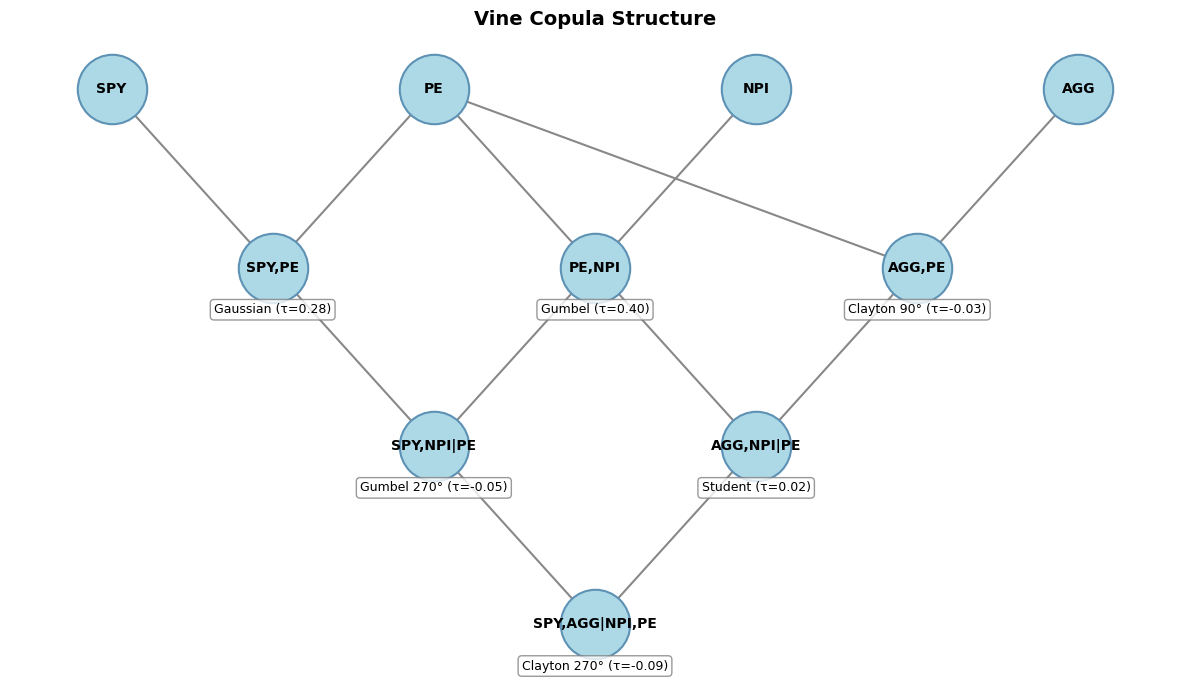

In [26]:
plot_vine_copula_structure()

In [27]:
dependence_heatmap_chart = plot_dependence_matrix_heatmap(
    marginals=marginals,
    copula=rvine_copula,
    asset_names=asset_names,
)

dependence_heatmap_chart

alt.HConcatChart(...)

In [28]:
pit_scatter_matrix_chart = plot_pit_scatter_matrix(
    marginals=marginals,
    copula=rvine_copula,
    asset_names=asset_names,
    max_points=2500,
)

pit_scatter_matrix_chart

alt.FacetChart(...)

In [29]:
historical_band_charts = {
    asset: plot_historical_return_time_series_with_garch_band(
        series=model_df[asset].dropna(),
        marginal=marginal,
    )
    for asset, marginal in zip(asset_names, marginals, strict=False)
}

historical_band_charts['SPY']

alt.LayerChart(...)

In [30]:
bootstrap_cvar_ci_chart = plot_bootstrap_cvar_ci(
    returns=simulation["compounded_return"],
    alpha=0.05,
    n_boot=5000,
    ci=0.95,
    seed=RNG_SEED,
)

bootstrap_cvar_ci_chart

alt.LayerChart(...)

In [31]:
asset_path_chart = plot_asset_path(simulation, path_id=0, asset_names=asset_cols)

asset_path_chart

alt.Chart(...)

In [32]:
simulation_chart = plot_simulations(simulation=simulation,
    historical_portfolio_return=model_df @ simulation['weights'],
    risk_summary=risk_summary,
    n_paths=2000,
    random_seed=67       # omit for a fresh random draw each time
)

simulation_chart

alt.HConcatChart(...)

In [33]:
quarter_return_charts = {asset: plot_quarter_return_hist(simulation, asset, step=0.01) for asset in asset_names}

quarter_return_charts['SPY']

alt.LayerChart(...)

In [34]:
quarter_return_charts['AGG']

alt.LayerChart(...)

In [35]:
quarter_return_charts['PE']

alt.LayerChart(...)

In [36]:
quarter_return_charts['NPI']

alt.LayerChart(...)

In [37]:
compound_return_dist_charts = {asset: plot_compound_return_dist_by_asset(simulation, asset) for asset in asset_names}

compound_return_dist_charts['SPY']

alt.LayerChart(...)

In [38]:
compound_return_dist_charts['AGG']

alt.LayerChart(...)

In [39]:
compound_return_dist_charts['PE']

alt.LayerChart(...)

In [40]:
compound_return_dist_charts['AGG']

alt.LayerChart(...)